In [1]:
# Datos adaptados de: https://www.kaggle.com/competitions/sentiment-analysis-on-movie-reviews/data

import csv

# Ruta a tu archivo de etiquetas
Train_sentiment = 'Train_Sentiment_complete.csv'

# Leer el archivo CSV y convertirlo en una lista de tuplas
data = []
try:
    with open(Train_sentiment, newline='', encoding='utf-8') as csvfile:
        # Usa DictReader con el delimitador correcto
        reader = csv.DictReader(csvfile, delimiter=';')
        for line_num, row in enumerate(reader, start=1):
            phrase = row.get('Phrase')
            sentiment = row.get('Sentiment')
            if phrase and sentiment:
                data.append((phrase, sentiment))
            else:
                print(f"Advertencia: Línea incorrecta en {line_num}: {row}")
except FileNotFoundError as e:
    print("Error: El archivo no fue encontrado.", e)
except csv.Error as e:
    print("Error al leer el archivo CSV:", e)

# Mostrar las primeras filas de la lista de tuplas para verificar que se ha leído correctamente
for i in range(min(5, len(data))):
    print(data[i])

# Mostrar la cantidad total de datos leídos
print()
print(f"Cantidad total de datos leídos: {len(data)}")

('A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .', '1')
('A series of escapades demonstrating the adage that what is good for the goose', '2')
('A series', '2')
('A', '2')
('series', '2')

Cantidad total de datos leídos: 156060


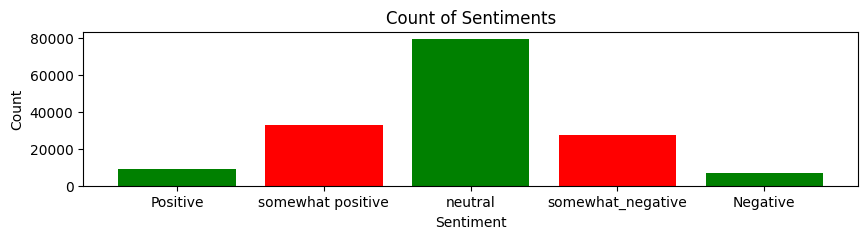

Positive count: 9206
somewhat positive: 32927
neutral count: 79582
somewhat_negative count: 27273
Negative count: 7072


In [2]:
# Contar la cantidad de comentarios positivos y negativos
import matplotlib.pyplot as plt

positive_count = sum(1 for _, label in data if label == "4")
somewhat_positive_count = sum(1 for _, label in data if label == "3")
neutral_count = sum(1 for _, label in data if label == "2")
somewhat_negative_count = sum(1 for _, label in data if label == "1")
negative_count = sum(1 for _, label in data if label == "0")

# Crear la gráfica
labels = ['Positive', 'somewhat positive', 'neutral', 'somewhat_negative','Negative']
counts = [positive_count, somewhat_positive_count, neutral_count, somewhat_negative_count, negative_count]

plt.figure(figsize=(10, 2))  # Ancho 6 pulgadas, Alto 4 pulgadas
plt.bar(labels, counts, color=['green', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Count of Sentiments')
plt.show()
print("Positive count:",positive_count)
print("somewhat positive:",somewhat_positive_count)
print("neutral count:",neutral_count)
print("somewhat_negative count:",somewhat_negative_count)
print("Negative count:",negative_count)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


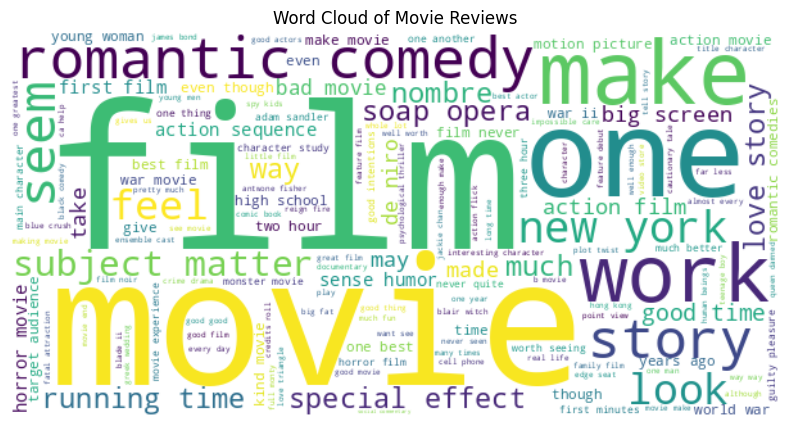

In [3]:
# Muertra la nube de palabras

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('stopwords')

# Preprocesar los textos
all_words = []
stop_words = set(stopwords.words('english'))

for text, label in data:
    words = word_tokenize(text.lower())  # Tokenizar y convertir a minúsculas
    words = [word for word in words if word.isalnum() and word not in stop_words]  # Eliminar puntuación y stopwords
    all_words.extend(words)

# Crear la nube de palabras
wordcloud = WordCloud(width=600, height=300, background_color='white').generate(' '.join(all_words))

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Reviews')
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


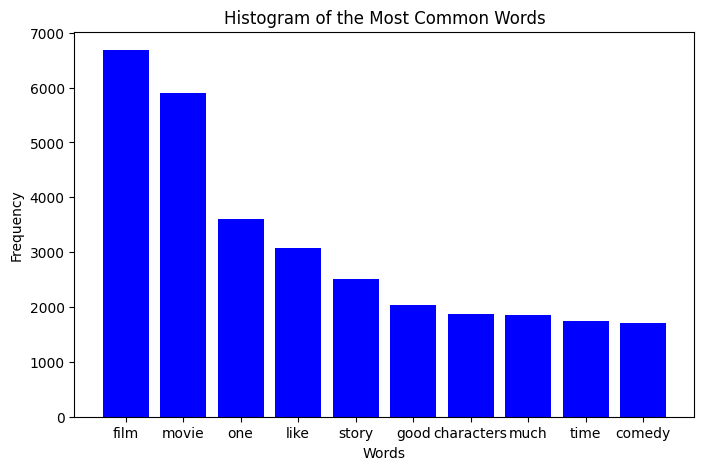

In [4]:
# Muestra el histograma de las palabras

import matplotlib.pyplot as plt
from collections import Counter

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('stopwords')

# Preprocesar los textos
all_words = []
stop_words = set(stopwords.words('english'))

for text, label in data:
    words = word_tokenize(text.lower())  # Tokenizar y convertir a minúsculas
    words = [word for word in words if word.isalnum() and word not in stop_words]  # Eliminar puntuación y stopwords
    all_words.extend(words)

# Contar la frecuencia de las palabras
word_freq = Counter(all_words)

# Seleccionar las palabras más comunes
common_words = word_freq.most_common(10)

# Crear listas de palabras y sus frecuencias
words = [word for word, freq in common_words]
frequencies = [freq for word, freq in common_words]

# Generar el histograma
plt.figure(figsize=(8, 5))
plt.bar(words, frequencies, color='blue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Histogram of the Most Common Words')
plt.show()

In [5]:
import pandas as pd

# Convertir la lista de tuplas en un DataFrame
df = pd.DataFrame(data, columns=['Phrase', 'Sentiment'])

# Mostrar las primeras filas del DataFrame para verificar
print(df.head())

# Mostrar la cantidad total de datos en el DataFrame
print(f"Cantidad total de datos en el DataFrame: {len(df)}")

                                              Phrase Sentiment
0  A series of escapades demonstrating the adage ...         1
1  A series of escapades demonstrating the adage ...         2
2                                           A series         2
3                                                  A         2
4                                             series         2
Cantidad total de datos en el DataFrame: 156060


In [7]:
# Determinar el tipo de datos de cada columna
print(df.dtypes)

Phrase       object
Sentiment    object
dtype: object


In [8]:
# Crear la lista de frases
review = list(df['Phrase'])

# Verificar el resultado: Imprimir las primeras 10 frases
print("Primeras 10 frases:")
print(review[:10])

Primeras 10 frases:
['A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .', 'A series of escapades demonstrating the adage that what is good for the goose', 'A series', 'A', 'series', 'of escapades demonstrating the adage that what is good for the goose', 'of', 'escapades demonstrating the adage that what is good for the goose', 'escapades', 'demonstrating the adage that what is good for the goose']


In [9]:
# Mostrar los valores únicos en la columna 'Sentiment' para verificar su contenido
print("Valores únicos en 'Sentiment':")
print(df['Sentiment'].unique())

# Crear etiquetas tal como están en la columna 'Sentiment'
labels = df['Sentiment'].values

# Verificar el resultado: Imprimir las primeras 10 etiquetas
print("Primeras 10 etiquetas:")
print(labels[:10])

Valores únicos en 'Sentiment':
['1' '2' '3' '4' '0']
Primeras 10 etiquetas:
['1' '2' '2' '2' '2' '2' '2' '2' '2' '2']


In [10]:
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.utils import to_categorical

# División de datos de entrenamiento y prueba
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.20, random_state=42)

# Asegurarse de que las etiquetas sean números
train_labels = train_labels.astype(int)
test_labels = test_labels.astype(int)

# Convertir las etiquetas a one-hot encoding para la clasificación multiclase
train_labels = to_categorical(train_labels, num_classes=5)
test_labels = to_categorical(test_labels, num_classes=5)

# Verificar el resultado
print(train_labels[:10])  # Imprime las primeras 10 etiquetas para verificar

[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [11]:
# Mostrar algunos ejemplos del conjunto de entrenamiento

print(f"Review: {train_sentences[:5]}")
print(f"Label: {train_labels[:5]}")

Review: ['cheesy', 'unintentionally -RRB-', "will need all the luck they can muster just figuring out who 's who in this pretentious mess", 'somewhere between Sling Blade and South of Heaven , West of Hell', "reminds at every turn of Elizabeth Berkley 's flopping dolphin-gasm"]
Label: [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]]


In [12]:
# Parámetros de configuración
vocab_size = 10000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

In [17]:
pip install tensorflow

In [18]:
#tokenización y acolchado de secuencias

import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Inicializar el Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)

# Generar el índice de palabras a partir de las frases de entrenamiento
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index

# Generar y acolchar las secuencias de entrenamiento
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

# Generar y acolchar las secuencias de prueba
test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

In [26]:
# Construcción del modelo

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(64, return_sequences=True), # Primera capa LSTM con return_sequences=True
    Dropout(0.25),
    LSTM(32), # Segunda capa LSTM de 32 unidades
    Dropout(0.25),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(5, activation='softmax') # Softmax para clasificación multiclase
])

In [27]:
#Construcción del modelo

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Resumen del modelo
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 447s 113ms/step - accuracy: 0.5365 - loss: 1.2373 - val_accuracy: 0.6241 - val_loss: 0.9415
Epoch 2/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 458s 117ms/step - accuracy: 0.6492 - loss: 0.8810 - val_accuracy: 0.6461 - val_loss: 0.8765
Epoch 3/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 487s 113ms/step - accuracy: 0.6742 - loss: 0.8112 - val_accuracy: 0.6550 - val_loss: 0.8486
Epoch 4/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 501s 113ms/step - accuracy: 0.6885 - loss: 0.7726 - val_accuracy: 0.6663 - val_loss: 0.8308
Epoch 5/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 502s 113ms/step - accuracy: 0.7039 - loss: 0.7378 - val_accuracy: 0.6662 - val_loss: 0.8284
Epoch 6/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 504s 114ms/step - accuracy: 0.7150 - loss: 0.7074 - val_accuracy: 0.6676 - val_loss: 0.8290
Epoch 7/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 505s 115ms/step - accuracy: 0.7273 - loss: 0.6846 - val_accuracy: 0.6669 - val_loss: 0.8337
Epoch 8/10
3902/3902 ━━━━━━━━━━━━━━━━━━━━ 520s 119ms/step - ac

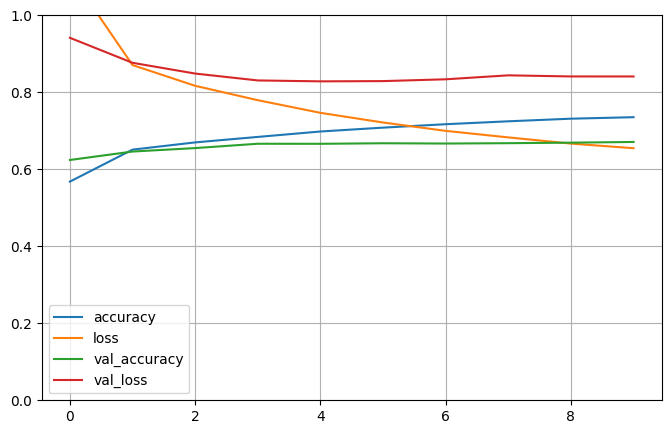

In [28]:
#train the model
import matplotlib.pyplot as plt

num_epochs = 10

history = model.fit(padded,
                    train_labels,
                    epochs=num_epochs,
                    validation_data=(test_padded, test_labels))

# Graficar el historial de entrenamiento
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()


976/976 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step


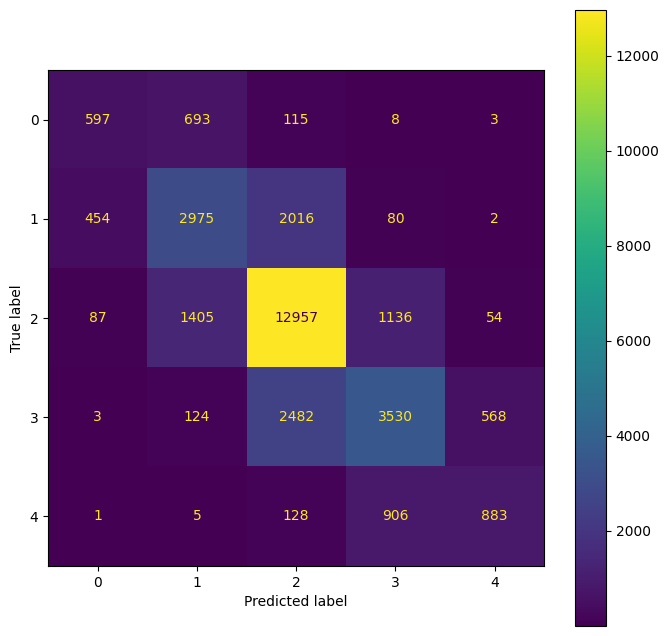

Accuracy: 0.67
F1 Score: 0.66
Accuracy: 0.67
F1 Score: 0.66


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

# Obtener las predicciones del modelo sobre el conjunto de prueba
predictions = model.predict(test_padded)

# Para clasificación multiclase, seleccionar la clase con mayor probabilidad
predicted_labels = np.argmax(predictions, axis=1)

# Convertir las etiquetas verdaderas de one-hot encoding a índices de clase
true_labels = np.argmax(test_labels, axis=1)

# Calcular la accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

# Calcular el F1 score con promedio adecuado para multiclase
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Crear la matriz de confusión
cm = confusion_matrix(true_labels, predicted_labels)

# Crear la visualización de la matriz de confusión con etiquetas automáticas
labels = sorted(set(true_labels))  # Extraer etiquetas únicas de true_labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Graficar la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)
plt.show()

# Mostrar la accuracy y el F1 score
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")

# Mostrar la accuracy y el F1 score
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")


976/976 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step


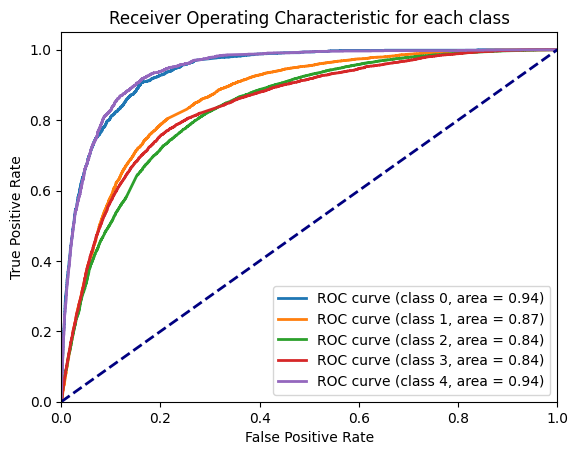

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# test_labels binarizado para cada clase
test_labels_bin = label_binarize(test_labels, classes=[0, 1, 2, 3, 4])

# Obtener las probabilidades de las predicciones para cada clase
y_prob = model.predict(test_padded)

# Graficar la curva ROC para cada clase
plt.figure()
for i in range(test_labels_bin.shape[1]):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (class {i}, area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for each class')
plt.legend(loc='lower right')
plt.show()

976/976 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step


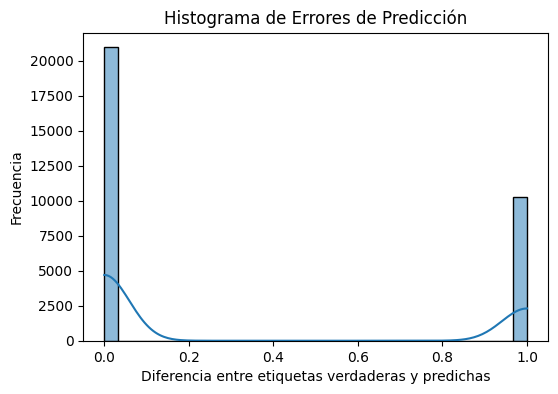

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener las probabilidades de predicción del modelo
y_prob = model.predict(test_padded)

# Obtener la clase con la mayor probabilidad como predicción
y_pred = np.argmax(y_prob, axis=1)

# Convertir las etiquetas verdaderas de one-hot encoding a índices de clase
y_true = np.argmax(test_labels, axis=1)

# Calcular los errores como la diferencia entre las etiquetas verdaderas y las predicciones
errors = y_true != y_pred  # True si incorrecto, False si correcto

# Crear el histograma de errores con barras más delgadas
plt.figure(figsize=(6, 4))
sns.histplot(errors, kde=True, bins=30)
plt.xlabel('Diferencia entre etiquetas verdaderas y predichas')
plt.ylabel('Frecuencia')
plt.title('Histograma de Errores de Predicción')
plt.show()